### Estadistica Descriptiva

In [1]:
import pandas as pd 
import numpy as np 


In [45]:
n_estudiantes=500
random_seed=42
np.random.seed(random_seed)
df1=pd.DataFrame({
    'Puntaje':np.random.normal(loc=72,scale=12,size=n_estudiantes).clip(0,100),
    'Edad':np.random.choice([14,15,16,17,18],size=n_estudiantes,p=[0.15,0.25,0.30,0.20,0.10]),
    'Sexo':np.random.choice(['M','F'],size=n_estudiantes,p=[0.48,0.52]),
    'Escuela':np.random.choice(['Publica','Privada','Subvencionada'],size=n_estudiantes,p=[0.60,0.25,0.15]),
    'Comuna':'Comuna A'
})  
print(df1)   


       Puntaje  Edad Sexo        Escuela    Comuna
0    77.960570    16    F        Publica  Comuna A
1    70.340828    16    M        Publica  Comuna A
2    79.772262    15    F        Privada  Comuna A
3    90.276358    18    M        Publica  Comuna A
4    69.190160    16    M  Subvencionada  Comuna A
..         ...   ...  ...            ...       ...
495  78.466921    16    M        Privada  Comuna A
496  59.553046    16    M        Publica  Comuna A
497  69.715936    17    F        Publica  Comuna A
498  61.492581    15    F        Publica  Comuna A
499  55.406403    17    M        Publica  Comuna A

[500 rows x 5 columns]


#### Revisar tipo de variables

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Puntaje  500 non-null    float64
 1   Edad     500 non-null    int32  
 2   Sexo     500 non-null    object 
 3   Escuela  500 non-null    object 
 4   Comuna   500 non-null    object 
dtypes: float64(1), int32(1), object(3)
memory usage: 17.7+ KB


In [ ]:
df.columns
# puntaje: cuantitativa continua
# edad: cuantitativa discreta
# sexo: cualitativa nominal al ser texto F,M
# escuela: cualitativa nominal
# comuna: cualitativa nominal


Index(['Puntaje', 'Edad', 'Sexo', 'Escuela', 'Comuna'], dtype='object')

In [10]:
df['Edad'].unique()

array([16, 15, 18, 14, 17])

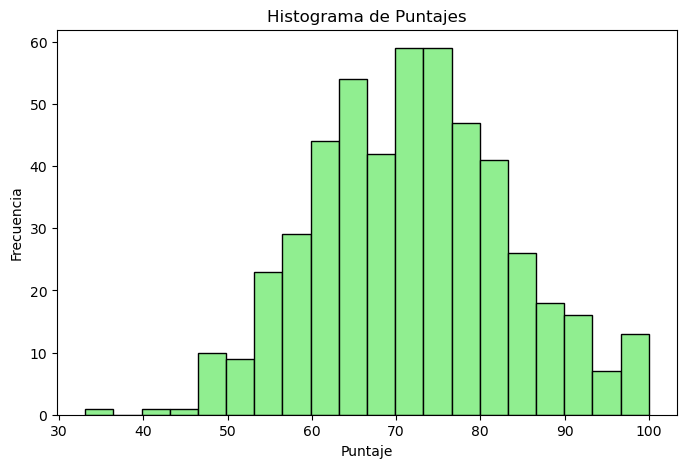

In [13]:
#histograma usando metodo de pandas
df['Puntaje'].plot(kind='hist',bins=20, color='lightgreen', edgecolor='black',figsize=(8,5))
plt.title('Histograma de Puntajes')
plt.xlabel('Puntaje')   
plt.ylabel('Frecuencia')
plt.show()

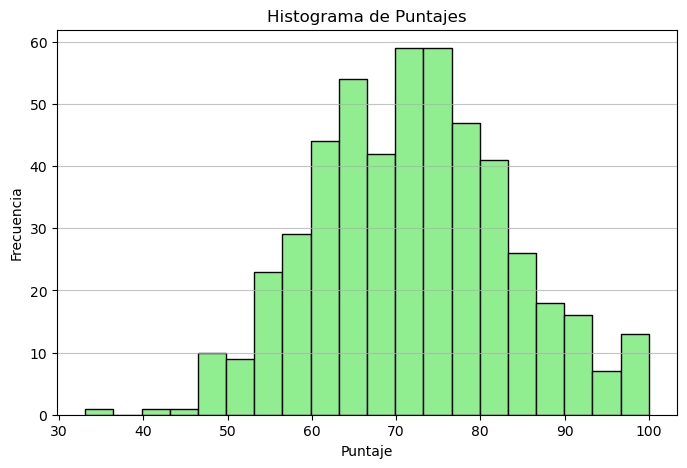

In [15]:
#Para variables continuas se usa histograma, para discretas y cualitativas se usa gráfico de barras.
import matplotlib.pyplot as plt

#generar histograma de puntaje
plt.figure(figsize=(8,5))
plt.hist(df['Puntaje'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Histograma de Puntajes')
plt.xlabel('Puntaje')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()




In [ ]:
#tabla de frecuencias para la variable edad
print(frecuencia_adsoluta)
frecuencia_adsoluta=df['Edad'].value_counts().sort_index()
frecuencia_relativa = df['Edad'].value_counts(normalize = True).sort_index() * 100
frecuencia_acumulada_abs = frecuencia_adsoluta.cumsum()
frecuencia_acumulada_rel = frecuencia_relativa.cumsum()

tabla_frecuencias=pd.DataFrame({
    'Frecuencia Absoluta':frecuencia_adsoluta,
    'Frecuencia Relativa (%)': frecuencia_relativa,
    'Frecuencia Acumulada Absoluta': frecuencia_acumulada_abs,
    'Frecuencia Acumulada Relativa (%)': frecuencia_acumulada_rel
})  
tabla_frecuencias


Edad
14     69
15    134
16    148
17     99
18     50
Name: count, dtype: int64


,Frecuencia Absoluta,Frecuencia Relativa (%),Frecuencia Acumulada Absoluta,Frecuencia Acumulada Relativa (%)
Edad,,,,
14,64,12.8,64,12.8
15,127,25.4,191,38.2
16,145,29.0,336,67.2
17,112,22.4,448,89.6
18,52,10.4,500,100.0


In [70]:
print(df['Edad'].value_counts().sort_index())
print(df['Edad'].unique())


Edad
14     64
15    127
16    145
17    112
18     52
Name: count, dtype: int64
[16 15 18 14 17]


In [35]:
df.describe(include='all')
df['Edad'].mode() # entrega todas las modad
df['Edad'].mode()[0] # entrega la primera moda
rango_edad=df['Edad'].max() - df['Edad'].min()
print('rango:', rango_edad)
varianza_edad=df['Edad'].var()
print('varianza:', varianza_edad)
desviacion_estandar_edad=df['Edad'].std()
print('desviación estándar:', desviacion_estandar_edad)


rango: 4
varianza: 1.3994829659318648
desviación estándar: 1.1829974496725955


In [66]:
# Tomar una muestra del DataFrame
muestra = df.sample(n=100, random_state=42)

# MEDIAS
# ========================
print('Media población:', df['Puntaje'].mean())
print('Media muestra:', muestra['Puntaje'].mean())

# ========================
# DESVIACIÓN ESTÁNDAR
# ========================
# Por defecto en Pandas (usa Bessel → ddof=1)
print('Desviación estándar (Pandas por defecto(usa Bessel → ddof=1)):', df['Puntaje'].std())

# Población (sin corrección de Bessel → ddof=0)
print('Desviación estándar población(sin corrección de Bessel → ddof=0)REAL:', df['Puntaje'].std(ddof=0))

# Muestra (con corrección de Bessel → ddof=1)
print('Desviación estándar muestra(con corrección de Bessel → ddof=1):', muestra['Puntaje'].std(ddof=1))

# ========================
# VARIANZA
# ========================
# Por defecto en Pandas (usa Bessel → ddof=1)
print('Varianza (Pandas por defecto(usa Bessel → ddof=1)):', df['Puntaje'].var())

# Población (sin Bessel)
print('Varianza población(sin Bessel)REAL:', df['Puntaje'].var(ddof=0))

# Muestra (con Bessel)
print('Varianza muestra(con Bessel):', muestra['Puntaje'].var(ddof=1))

Media población: 72.21453647221404
Media muestra: 71.26770977289682
Desviación estándar (Pandas por defecto(usa Bessel → ddof=1)): 11.889375275619962
Desviación estándar población(sin corrección de Bessel → ddof=0)REAL: 11.877479949704576
Desviación estándar muestra(con corrección de Bessel → ddof=1): 12.357382812726684
Varianza (Pandas por defecto(usa Bessel → ddof=1)): 141.35724444452325
Varianza población(sin Bessel)REAL: 141.0745299556342
Varianza muestra(con Bessel): 152.70490998027284


In [46]:
n_estudiantes=500
random_seed=43
np.random.seed(random_seed)
df2=pd.DataFrame({
    'Puntaje':np.random.normal(loc=72,scale=12,size=n_estudiantes).clip(0,100),
    'Edad':np.random.choice([14,15,16,17,18],size=n_estudiantes,p=[0.15,0.25,0.30,0.20,0.10]),
    'Sexo':np.random.choice(['M','F'],size=n_estudiantes,p=[0.48,0.52]),
    'Escuela':np.random.choice(['Publica','Privada','Subvencionada'],size=n_estudiantes,p=[0.60,0.25,0.15]),
    'Comuna':'Comuna B'
})  
print(df2)  

       Puntaje  Edad Sexo        Escuela    Comuna
0    75.088799    16    M        Publica  Comuna B
1    61.098223    15    M  Subvencionada  Comuna B
2    67.457963    18    F        Publica  Comuna B
3    65.581013    14    F  Subvencionada  Comuna B
4    82.296880    18    M        Privada  Comuna B
..         ...   ...  ...            ...       ...
495  78.597600    16    F        Publica  Comuna B
496  76.559760    17    M        Publica  Comuna B
497  46.443559    16    M        Publica  Comuna B
498  78.230532    15    F        Publica  Comuna B
499  79.740561    15    M        Privada  Comuna B

[500 rows x 5 columns]


In [48]:
df_completo=pd.concat([df1, df2], ignore_index=True)
print(df_completo)

       Puntaje  Edad Sexo        Escuela    Comuna
0    77.960570    16    F        Publica  Comuna A
1    70.340828    16    M        Publica  Comuna A
2    79.772262    15    F        Privada  Comuna A
3    90.276358    18    M        Publica  Comuna A
4    69.190160    16    M  Subvencionada  Comuna A
..         ...   ...  ...            ...       ...
995  78.597600    16    F        Publica  Comuna B
996  76.559760    17    M        Publica  Comuna B
997  46.443559    16    M        Publica  Comuna B
998  78.230532    15    F        Publica  Comuna B
999  79.740561    15    M        Privada  Comuna B

[1000 rows x 5 columns]


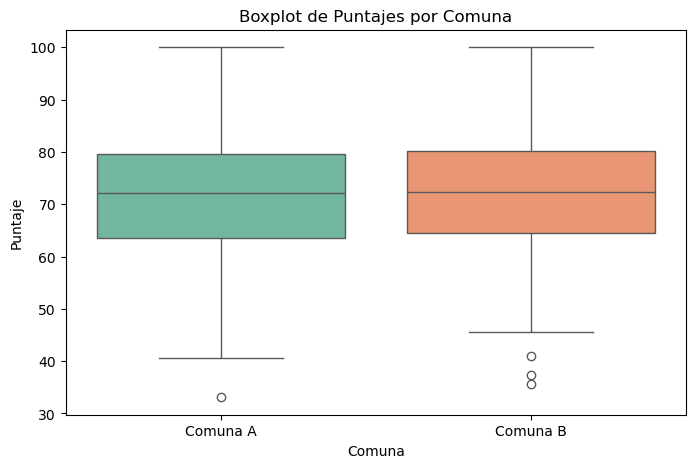

In [52]:
import seaborn as sns
#generear un boxplot comparativo de la variable puntaje por comuna
plt.figure(figsize=(8,5))
sns.boxplot(x='Comuna', y='Puntaje', data=df_completo, palette='Set2', hue='Comuna')
plt.title('Boxplot de Puntajes por Comuna')
plt.xlabel('Comuna')
plt.ylabel('Puntaje')
plt.show()

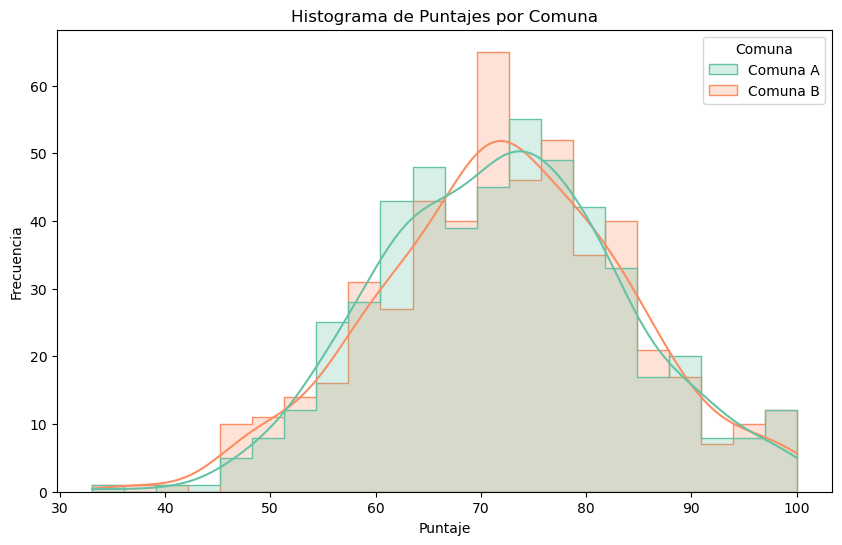

In [54]:
#comparar histogramas de puntajes por comuna
plt.figure(figsize=(10,6))
sns.histplot(data=df_completo, x='Puntaje', hue='Comuna', element='step', kde=True, palette='Set2')
plt.title('Histograma de Puntajes por Comuna')
plt.xlabel('Puntaje')
plt.ylabel('Frecuencia')
plt.show()